In [1]:
import shutil
import os
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle
from sklearn.manifold import TSNE
from sklearn import preprocessing
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import log_loss
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import MiniBatchKMeans
import numpy as np
from gtda.images import Binarizer
from gtda.images import RadialFiltration
from gtda.diagrams import Amplitude
from gtda.homology import CubicalPersistence
from gtda.diagrams import Scaler
from sklearn.pipeline import make_pipeline, make_union
from gtda.diagrams import PersistenceEntropy
from gtda.images import HeightFiltration
import pandas as pd
import matplotlib
import os

import warnings
warnings.filterwarnings("ignore")

In [37]:
data1 = pd.read_csv('tda_payload.csv')
dfdf3 =data1.iloc[:,:-1]
dfdf3

,payload_byte_1,payload_byte_2,payload_byte_3,payload_byte_4,payload_byte_5,payload_byte_6,payload_byte_7,payload_byte_8,payload_byte_9,payload_byte_10,...,payload_byte_1491,payload_byte_1492,payload_byte_1493,payload_byte_1494,payload_byte_1495,payload_byte_1496,payload_byte_1497,payload_byte_1498,payload_byte_1499,payload_byte_1500
0,66,80,83,33,32,55,98,32,66,80,...,0,0,0,0,0,0,0,0,0,0
1,66,80,83,33,32,53,52,32,66,80,...,0,0,0,0,0,0,0,0,0,0
2,66,80,83,33,32,57,32,66,80,83,...,0,0,0,0,0,0,0,0,0,0
3,66,80,83,33,32,56,51,32,66,80,...,0,0,0,0,0,0,0,0,0,0
4,66,80,83,33,32,57,32,66,80,83,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79876,80,79,83,84,32,47,120,109,108,114,...,0,0,0,0,0,0,0,0,0,0
79877,71,69,84,32,47,99,103,105,45,98,...,0,0,0,0,0,0,0,0,0,0
79878,80,79,83,84,32,47,98,108,111,103,...,0,0,0,0,0,0,0,0,0,0
79879,80,79,83,84,32,47,120,109,108,114,...,0,0,0,0,0,0,0,0,0,0


In [38]:
#random_rows=dfdf3.sample(10000)
#inlude_rows=dfdf3.iloc[50138:71138,:]

In [39]:
#  create a separate dataframe for the include_rows
include_rows = dfdf3.iloc[50138:71138,:]
#sample() function to randomly select additional rows excluding the included ones
random_rows = dfdf3[~dfdf3.index.isin(include_rows)].sample(n=10000)  # Select 10000 random rows excluding the included ones
#  create a separate dataframe for the include_rows
include_df = dfdf3.iloc[50138:71138,:]

In [40]:
dfdf31 = pd.read_csv('poisoned_file_to_integer.csv')
dfdf31

,1,2,3,4,5,6,7,8,9,10,...,1491,1492,1493,1494,1495,1496,1497,1498,1499,1500
0,103,101,84,32,47,63,52,120,117,102,...,0,0,0,0,0,0,0,0,0,0
1,71,69,116,32,47,63,52,120,85,102,...,0,0,0,0,0,0,0,0,0,0
2,71,69,116,32,47,63,52,88,85,102,...,0,0,0,0,0,0,0,0,0,0
3,103,69,116,32,47,63,52,88,85,70,...,0,0,0,0,0,0,0,0,0,0
4,103,101,84,32,47,63,52,88,85,102,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,80,79,83,116,32,47,68,86,47,76,...,0,0,0,0,0,0,0,0,0,0
996,112,79,115,116,32,47,68,86,47,76,...,0,0,0,0,0,0,0,0,0,0
997,112,79,115,116,32,47,68,86,47,76,...,0,0,0,0,0,0,0,0,0,0
998,112,79,115,116,32,47,68,86,47,76,...,0,0,0,0,0,0,0,0,0,0


In [41]:
random_rows

,payload_byte_1,payload_byte_2,payload_byte_3,payload_byte_4,payload_byte_5,payload_byte_6,payload_byte_7,payload_byte_8,payload_byte_9,payload_byte_10,...,payload_byte_1491,payload_byte_1492,payload_byte_1493,payload_byte_1494,payload_byte_1495,payload_byte_1496,payload_byte_1497,payload_byte_1498,payload_byte_1499,payload_byte_1500
51978,83,83,72,45,50,46,48,45,80,117,...,0,0,0,0,0,0,0,0,0,0
38208,225,2,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3449,0,0,0,157,255,83,77,66,115,0,...,0,0,0,0,0,0,0,0,0,0
64546,227,61,0,0,0,1,16,9,29,37,...,0,0,0,0,0,0,0,0,0,0
12591,84,226,214,60,196,110,192,239,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43739,29,228,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
24989,60,48,62,50,48,49,53,45,48,50,...,0,0,0,0,0,0,0,0,0,0
66248,255,140,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1068,71,69,84,32,47,119,121,50,112,87,...,0,0,0,0,0,0,0,0,0,0


In [42]:
include_df

,payload_byte_1,payload_byte_2,payload_byte_3,payload_byte_4,payload_byte_5,payload_byte_6,payload_byte_7,payload_byte_8,payload_byte_9,payload_byte_10,...,payload_byte_1491,payload_byte_1492,payload_byte_1493,payload_byte_1494,payload_byte_1495,payload_byte_1496,payload_byte_1497,payload_byte_1498,payload_byte_1499,payload_byte_1500
50138,227,61,0,0,0,1,16,153,97,67,...,0,0,0,0,0,0,0,0,0,0
50139,32,116,104,101,32,87,105,116,104,32,...,0,0,0,0,0,0,0,0,0,0
50140,227,17,0,0,0,88,180,77,187,210,...,0,0,0,0,0,0,0,0,0,0
50141,227,33,0,0,0,71,123,67,239,52,...,0,0,0,0,0,0,0,0,0,0
50142,19,66,105,116,84,111,114,114,101,110,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71133,227,17,0,0,0,84,181,212,164,153,...,0,0,0,0,0,0,0,0,0,0
71134,0,0,2,100,10,20,217,16,119,116,...,0,0,0,0,0,0,0,0,0,0
71135,227,17,0,0,0,84,157,232,114,7,...,0,0,0,0,0,0,0,0,0,0
71136,0,0,0,13,6,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [45]:
selected_rows = pd.concat([random_rows, include_df])

In [46]:
selected_rows

,payload_byte_1,payload_byte_2,payload_byte_3,payload_byte_4,payload_byte_5,payload_byte_6,payload_byte_7,payload_byte_8,payload_byte_9,payload_byte_10,...,payload_byte_1491,payload_byte_1492,payload_byte_1493,payload_byte_1494,payload_byte_1495,payload_byte_1496,payload_byte_1497,payload_byte_1498,payload_byte_1499,payload_byte_1500
51978,83,83,72,45,50,46,48,45,80,117,...,0,0,0,0,0,0,0,0,0,0
38208,225,2,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3449,0,0,0,157,255,83,77,66,115,0,...,0,0,0,0,0,0,0,0,0,0
64546,227,61,0,0,0,1,16,9,29,37,...,0,0,0,0,0,0,0,0,0,0
12591,84,226,214,60,196,110,192,239,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71133,227,17,0,0,0,84,181,212,164,153,...,0,0,0,0,0,0,0,0,0,0
71134,0,0,2,100,10,20,217,16,119,116,...,0,0,0,0,0,0,0,0,0,0
71135,227,17,0,0,0,84,157,232,114,7,...,0,0,0,0,0,0,0,0,0,0
71136,0,0,0,13,6,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
#inst = []
value_shape3 = []
for i in range(0, len(selected_rows)):
    rows1 = selected_rows.iloc[i]
    value_shape3.append(np.reshape(rows1.values, (1, 1500)))

In [11]:
input1_tda_pipe=np.array(value_shape3)
input1_tda_pipe.shape

(31000, 1, 1500)

In [12]:
input1_tda_pipe

array([[[ 66,  80,  83, ...,   0,   0,   0]],

       [[  6, 150,   1, ...,   0,   0,   0]],

       [[109,  35,   1, ...,   0,   0,   0]],

       ...,

       [[227,  17,   0, ...,   0,   0,   0]],

       [[  0,   0,   0, ...,   0,   0,   0]],

       [[227,  17,   0, ...,   0,   0,   0]]])

In [13]:
import numpy as np
from gtda.images import Binarizer
from gtda.images import RadialFiltration
from gtda.diagrams import Amplitude
from gtda.homology import CubicalPersistence
from gtda.diagrams import Scaler
from sklearn.pipeline import make_pipeline, make_union
from gtda.diagrams import PersistenceEntropy
from gtda.images import HeightFiltration
import pandas as pd
import matplotlib

direction_list = [[0,  1], [1, 0]]
center_list = [
    [0, 1500], [0, 600], [0, 750], [1500, 0], [600, 0]]

# Creating a list of all filtration transformer, we will be applying
filtration_list = (
    [
        HeightFiltration(direction=np.array(direction), n_jobs=-1)
        for direction in direction_list
    ]
    + [RadialFiltration(center=np.array(center), n_jobs=-1) for center in center_list])

# Creating the diagram generation pipeline
diagram_steps = [
    [
        Binarizer(threshold=0.3, n_jobs=-1),
        filtration,
        CubicalPersistence(n_jobs=-1),
        Scaler(n_jobs=-1),
    ]
    for filtration in filtration_list   ]
# Listing all metrics we want to use to extract diagram amplitudes
metric_list = [
    {"metric": "bottleneck", "metric_params": {}},
    {"metric": "wasserstein", "metric_params": {"p": 1}},
    {"metric": "landscape", "metric_params": {"p": 1, "n_layers": 1, "n_bins": 81}},
    {"metric": "landscape", "metric_params": {"p": 1, "n_layers": 2, "n_bins": 81}},
    {"metric": "betti", "metric_params": {"p": 1, "n_bins": 81}},
    {"metric": "betti", "metric_params": {"p": 2, "n_bins": 81}},
    {"metric": "heat", "metric_params": {"p": 1, "sigma": 1.6, "n_bins": 81}},
    {"metric": "heat", "metric_params": {"p": 1, "sigma": 3.2, "n_bins": 81}}  ]
#
feature_union = make_union(
    *[PersistenceEntropy(nan_fill_value=-1)]
    + [Amplitude(**metric, n_jobs=-1) for metric in metric_list]
)

tda_union = make_union(
    *[make_pipeline(*diagram_step, feature_union) for diagram_step in diagram_steps],
    n_jobs=-1)

In [14]:
from  sklearn import set_config
set_config(display='diagram')

tda_union

FeatureUnion(n_jobs=-1,
             transformer_list=[('pipeline-1',
                                Pipeline(steps=[('binarizer',
                                                 Binarizer(n_jobs=-1,
                                                           threshold=0.3)),
                                                ('heightfiltration',
                                                 HeightFiltration(direction=array([0, 1]),
                                                                  n_jobs=-1)),
                                                ('cubicalpersistence',
                                                 CubicalPersistence(n_jobs=-1)),
                                                ('scaler', Scaler(n_jobs=-1)),
                                                ('featureunion',
                                                 FeatureUnion(transformer_list=[('persistenceentropy',
                                                                                 Persist...
                                                                                 Amplitude(metric='betti',
                                                                                           metric_params={'n_bins': 81,
                                                                                                          'p': 1},
                                                                                           n_jobs=-1)),
                                                                                ('amplitude-6',
                                                                                 Amplitude(metric='betti',
                                                                                           metric_params={'n_bins': 81,
                                                                                                          'p': 2},
                                                                                           n_jobs=-1)),
                                                                                ('amplitude-7',
                                                                                 Amplitude(metric='heat',
                                                                                           metric_params={'n_bins': 81,
                                                                                                          'p': 1,
                                                                                                          'sigma': 1.6},
                                                                                           n_jobs=-1)),
                                                                                ('amplitude-8',
                                                                                 Amplitude(metric='heat',
                                                                                           metric_params={'n_bins': 81,
                                                                                                          'p': 1,
                                                                                                          'sigma': 3.2},
                                                                                           n_jobs=-1))]))]))])

In [15]:
X_begnin = tda_union.fit_transform(input1_tda_pipe)

In [16]:
X_begnin

array([[ 3.169925  , -1.        ,  1.        , ...,  0.        ,
         0.02609332,  0.        ],
       [ 2.        , -1.        ,  1.        , ...,  0.        ,
         0.01092454,  0.        ],
       [ 2.32192809, -1.        ,  1.        , ...,  0.        ,
         0.0138022 ,  0.        ],
       ...,
       [ 2.        , -1.        ,  1.        , ...,  0.        ,
         0.01063142,  0.        ],
       [-1.        , -1.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 2.        , -1.        ,  1.        , ...,  0.        ,
         0.01063142,  0.        ]])

In [17]:
X_begnin1 = pd.DataFrame(X_begnin)
X_begnin1

,0,1,2,3,4,5,6,7,8,9,...,116,117,118,119,120,121,122,123,124,125
0,3.169925,-1.0,1.0,0.0,9.0,0.0,1.0,0.0,2.0,0.0,...,0.324271,0.0,6.575,0.0,7.551490,0.0,0.322772,0.0,0.026093,0.0
1,2.000000,-1.0,1.0,0.0,4.0,0.0,1.0,0.0,2.0,0.0,...,0.254889,0.0,2.750,0.0,3.293934,0.0,0.134741,0.0,0.010925,0.0
2,2.321928,-1.0,1.0,0.0,5.0,0.0,1.0,0.0,2.0,0.0,...,0.269411,0.0,3.475,0.0,4.132191,0.0,0.170328,0.0,0.013802,0.0
3,4.584963,-1.0,1.0,0.0,24.0,0.0,1.0,0.0,2.0,0.0,...,0.550140,0.0,21.050,0.0,21.647171,0.0,1.035297,0.0,0.083242,0.0
4,8.055282,-1.0,1.0,0.0,266.0,0.0,1.0,0.0,2.0,0.0,...,1.993326,0.0,301.425,0.0,242.098895,0.0,13.883215,0.0,1.165700,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30995,1.000000,-1.0,1.0,0.0,2.0,0.0,1.0,0.0,2.0,0.0,...,0.229383,0.0,1.325,0.0,1.620185,0.0,0.064833,0.0,0.005267,0.0
30996,6.629357,-1.0,1.0,0.0,99.0,0.0,1.0,0.0,2.0,0.0,...,1.957773,0.0,130.850,0.0,103.828946,0.0,6.022077,0.0,0.504793,0.0
30997,2.000000,-1.0,1.0,0.0,4.0,0.0,1.0,0.0,2.0,0.0,...,0.240095,0.0,2.675,0.0,3.259601,0.0,0.130935,0.0,0.010631,0.0
30998,-1.000000,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0


In [18]:
X_begnin1.to_csv('tda_begnin_X_126.csv', index=False)

In [3]:
# Read the tda_poisoned CSV file into a dataframe
df11 = pd.read_csv('tda_poisoned_X_126.csv')

# Read the begnin CSV file into another dataframe
df22 = pd.read_csv('tda_begnin_X_126.csv')

# Concatenate the dataframes vertically
combined_df12 = pd.concat([df11, df22], ignore_index=True)
# Alternatively, you can concatenate the dataframes horizontally
# combined_df = pd.concat([df1, df2], axis=1)

# Display the combined dataframe
print(combined_df12)

              0    1    2    3     4    5    6    7    8    9  ...       116   
0      4.954196 -1.0  1.0  0.0  31.0  0.0  1.0  0.0  2.0  0.0  ...  1.879522  \
1      4.954196 -1.0  1.0  0.0  31.0  0.0  1.0  0.0  2.0  0.0  ...  1.879522   
2      4.954196 -1.0  1.0  0.0  31.0  0.0  1.0  0.0  2.0  0.0  ...  1.879522   
3      4.954196 -1.0  1.0  0.0  31.0  0.0  1.0  0.0  2.0  0.0  ...  1.879522   
4      4.954196 -1.0  1.0  0.0  31.0  0.0  1.0  0.0  2.0  0.0  ...  1.879522   
...         ...  ...  ...  ...   ...  ...  ...  ...  ...  ...  ...       ...   
31995  1.000000 -1.0  1.0  0.0   2.0  0.0  1.0  0.0  2.0  0.0  ...  0.229383   
31996  6.629357 -1.0  1.0  0.0  99.0  0.0  1.0  0.0  2.0  0.0  ...  1.957773   
31997  2.000000 -1.0  1.0  0.0   4.0  0.0  1.0  0.0  2.0  0.0  ...  0.240095   
31998 -1.000000 -1.0  0.0  0.0   0.0  0.0  0.0  0.0  0.0  0.0  ...  0.000000   
31999  2.000000 -1.0  1.0  0.0   4.0  0.0  1.0  0.0  2.0  0.0  ...  0.240095   

       117      118  119         120  1

In [20]:
pd.DataFrame(combined_df12)

,0,1,2,3,4,5,6,7,8,9,...,116,117,118,119,120,121,122,123,124,125
0,4.954196,-1.0,1.0,0.0,31.0,0.0,1.0,0.0,2.0,0.0,...,1.879522,0.0,40.175,0.0,32.707415,0.0,1.871993,0.0,0.155537,0.0
1,4.954196,-1.0,1.0,0.0,31.0,0.0,1.0,0.0,2.0,0.0,...,1.879522,0.0,40.175,0.0,32.707415,0.0,1.871993,0.0,0.155537,0.0
2,4.954196,-1.0,1.0,0.0,31.0,0.0,1.0,0.0,2.0,0.0,...,1.879522,0.0,40.175,0.0,32.707415,0.0,1.871993,0.0,0.155537,0.0
3,4.954196,-1.0,1.0,0.0,31.0,0.0,1.0,0.0,2.0,0.0,...,1.879522,0.0,40.175,0.0,32.707415,0.0,1.871993,0.0,0.155537,0.0
4,4.954196,-1.0,1.0,0.0,31.0,0.0,1.0,0.0,2.0,0.0,...,1.879522,0.0,40.175,0.0,32.707415,0.0,1.871993,0.0,0.155537,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31995,1.000000,-1.0,1.0,0.0,2.0,0.0,1.0,0.0,2.0,0.0,...,0.229383,0.0,1.325,0.0,1.620185,0.0,0.064833,0.0,0.005267,0.0
31996,6.629357,-1.0,1.0,0.0,99.0,0.0,1.0,0.0,2.0,0.0,...,1.957773,0.0,130.850,0.0,103.828946,0.0,6.022077,0.0,0.504793,0.0
31997,2.000000,-1.0,1.0,0.0,4.0,0.0,1.0,0.0,2.0,0.0,...,0.240095,0.0,2.675,0.0,3.259601,0.0,0.130935,0.0,0.010631,0.0
31998,-1.000000,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0


In [21]:
combined_df12.to_csv('poinsoned_begnin_X_126.csv', index=False)

In [4]:
dff1=pd.read_csv('poinsoned_begnin_X_126.csv')

In [5]:
dff1

,0,1,2,3,4,5,6,7,8,9,...,116,117,118,119,120,121,122,123,124,125
0,4.954196,-1.0,1.0,0.0,31.0,0.0,1.0,0.0,2.0,0.0,...,1.879522,0.0,40.175,0.0,32.707415,0.0,1.871993,0.0,0.155537,0.0
1,4.954196,-1.0,1.0,0.0,31.0,0.0,1.0,0.0,2.0,0.0,...,1.879522,0.0,40.175,0.0,32.707415,0.0,1.871993,0.0,0.155537,0.0
2,4.954196,-1.0,1.0,0.0,31.0,0.0,1.0,0.0,2.0,0.0,...,1.879522,0.0,40.175,0.0,32.707415,0.0,1.871993,0.0,0.155537,0.0
3,4.954196,-1.0,1.0,0.0,31.0,0.0,1.0,0.0,2.0,0.0,...,1.879522,0.0,40.175,0.0,32.707415,0.0,1.871993,0.0,0.155537,0.0
4,4.954196,-1.0,1.0,0.0,31.0,0.0,1.0,0.0,2.0,0.0,...,1.879522,0.0,40.175,0.0,32.707415,0.0,1.871993,0.0,0.155537,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31995,1.000000,-1.0,1.0,0.0,2.0,0.0,1.0,0.0,2.0,0.0,...,0.229383,0.0,1.325,0.0,1.620185,0.0,0.064833,0.0,0.005267,0.0
31996,6.629357,-1.0,1.0,0.0,99.0,0.0,1.0,0.0,2.0,0.0,...,1.957773,0.0,130.850,0.0,103.828946,0.0,6.022077,0.0,0.504793,0.0
31997,2.000000,-1.0,1.0,0.0,4.0,0.0,1.0,0.0,2.0,0.0,...,0.240095,0.0,2.675,0.0,3.259601,0.0,0.130935,0.0,0.010631,0.0
31998,-1.000000,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0


In [27]:
data12=pd.read_csv('poinsoned_begnin_X_126.csv')

In [28]:
data13=np.array(data12)

In [29]:
#data_test=np.array(data)

In [30]:
X_train2, X_test2 = train_test_split(data12, test_size = 0.5,random_state=60)#42 ,56;// state 6 , tes_size=0.2 estimator=750 acc=76
X_train2, X_test2

(              0    1    2    3     4    5    6    7    8    9  ...       116   
 20275  2.807355 -1.0  1.0  0.0   7.0  0.0  1.0  0.0  2.0  0.0  ...  0.269362  \
 23088  1.584963 -1.0  1.0  0.0   3.0  0.0  1.0  0.0  2.0  0.0  ...  0.247881   
 14447  2.321928 -1.0  1.0  0.0   5.0  0.0  1.0  0.0  2.0  0.0  ...  0.247102   
 18788  2.000000 -1.0  1.0  0.0   4.0  0.0  1.0  0.0  2.0  0.0  ...  0.254889   
 15406 -1.000000 -1.0  0.0  0.0   0.0  0.0  0.0  0.0  0.0  0.0  ...  0.000000   
 ...         ...  ...  ...  ...   ...  ...  ...  ...  ...  ...  ...       ...   
 6543   0.000000 -1.0  1.0  0.0   1.0  0.0  1.0  0.0  1.0  0.0  ...  0.114986   
 17802  2.807355 -1.0  1.0  0.0   7.0  0.0  1.0  0.0  2.0  0.0  ...  0.310923   
 11846  1.584963 -1.0  1.0  0.0   3.0  0.0  1.0  0.0  2.0  0.0  ...  0.240873   
 3137   5.392317 -1.0  1.0  0.0  42.0  0.0  1.0  0.0  2.0  0.0  ...  0.896759   
 2253   2.321928 -1.0  1.0  0.0   5.0  0.0  1.0  0.0  2.0  0.0  ...  0.247102   
 
        117     118  119  

In [31]:
from sklearn.cluster import DBSCAN
#from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

dbscan = DBSCAN(eps=200, min_samples=500)#eps=1' min_s=2500
y_dbscan = dbscan.fit_predict(X_train2)
silhouette_avg = silhouette_score(X_train2, y_dbscan)
print("Silhouette score:", silhouette_avg)
np.unique(y_dbscan)

Silhouette score: 0.8878544932618142


array([-1,  0,  1])

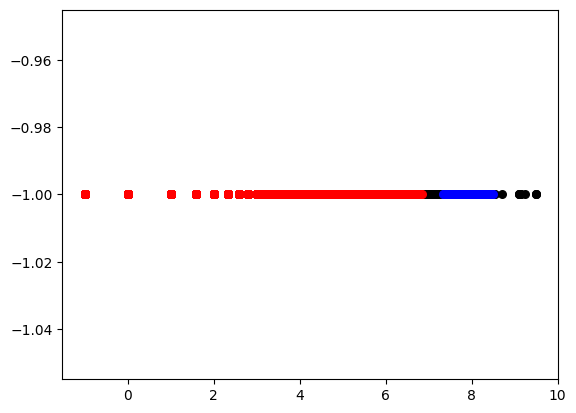

In [32]:
plt.scatter(X_train2.iloc[y_dbscan==-1, 0],X_train2.iloc[y_dbscan==-1, 1],s=30,  c='black')
plt.scatter(X_train2.iloc[y_dbscan==0, 0],X_train2.iloc[y_dbscan==0, 1],s=30,  c='red')
plt.scatter(X_train2.iloc[y_dbscan==1, 0],X_train2.iloc[y_dbscan==1, 1],s=30,  c='blue')
plt.show()

In [25]:
X_train_b, X_test_b = train_test_split(df22, test_size = 0.5 ,random_state=60)#42 ,56;// state 6 , tes_size=0.2 estimator=750 acc=76
X_train_b, X_test_b

(              0    1    2    3      4    5    6    7    8    9  ...       116   
 27806  6.629357 -1.0  1.0  0.0   99.0  0.0  1.0  0.0  2.0  0.0  ...  1.957773  \
 5878   2.000000 -1.0  1.0  0.0    4.0  0.0  1.0  0.0  2.0  0.0  ...  0.254889   
 24285 -1.000000 -1.0  0.0  0.0    0.0  0.0  0.0  0.0  0.0  0.0  ...  0.000000   
 14226  2.321928 -1.0  1.0  0.0    5.0  0.0  1.0  0.0  2.0  0.0  ...  0.247881   
 22663 -1.000000 -1.0  0.0  0.0    0.0  0.0  0.0  0.0  0.0  0.0  ...  0.000000   
 ...         ...  ...  ...  ...    ...  ...  ...  ...  ...  ...  ...       ...   
 6543   4.459432 -1.0  1.0  0.0   22.0  0.0  1.0  0.0  2.0  0.0  ...  0.513348   
 17802 -1.000000 -1.0  0.0  0.0    0.0  0.0  0.0  0.0  0.0  0.0  ...  0.000000   
 11846  8.280771 -1.0  1.0  0.0  311.0  0.0  1.0  0.0  2.0  0.0  ...  1.977753   
 3137   5.584963 -1.0  1.0  0.0   48.0  0.0  1.0  0.0  2.0  0.0  ...  0.949759   
 2253   3.584963 -1.0  1.0  0.0   12.0  0.0  1.0  0.0  2.0  0.0  ...  0.291053   
 
        117   

In [20]:
dbscan = DBSCAN(eps=11,min_samples=100)#eps=1' min_s=2500
y_dbscan = dbscan.fit_predict(X_train_b)
silhouette_avg = silhouette_score(X_train_b, y_dbscan)
print("Silhouette score:", silhouette_avg)
np.unique(y_dbscan)

Silhouette score: 0.5610744257736724


array([-1,  0,  1,  2])

In [21]:
import plotly.express as px

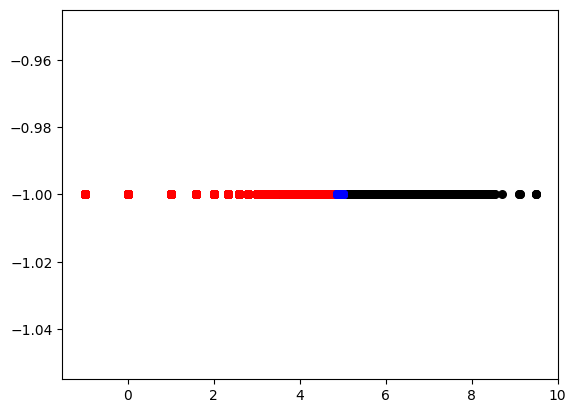

In [26]:
plt.scatter(X_train_b.iloc[y_dbscan==-1, 0],X_train_b.iloc[y_dbscan==-1, 1],s=30,  c='black')
plt.scatter(X_train_b.iloc[y_dbscan==0, 0],X_train_b.iloc[y_dbscan==0, 1],s=30,  c='red')
plt.scatter(X_train_b.iloc[y_dbscan==1, 0],X_train_b.iloc[y_dbscan==1, 1],s=30,  c='blue')
plt.show()